# 1D FWI implementation via ODIL

In this notebook, I will extend what I have learnt of ODIL from reproducing Figure 1 in the [`/reproduction`](./../reproduction/) notebooks. Our task will be to jointly optimise for an amplitude field and a wavespeed field using the ODIL framework. This will involve introducing a source term, the concept of 'receievers' (discrete observation points), and a data misfit.

To start, we can update our `Wavefield` class to include a wavespeed model in its data vector. It is important we keep the wavespeed and ampltiude data together. If we do not perform a joint optimisation and instead optimise the two field separately, the wave equation solve will be chasing an expired wavespeed model. 

In [51]:
from dataclasses import dataclass, field
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt

In [52]:
@dataclass
class Wavefield:
    # spatial data
    x_0: float = -1.0
    x_I: float = 1.0
    I: int = 25
    L: float = field(init=False)
    dx: float = field(init=False)

    # temporal data
    t_0: float = 0.0
    t_N: float = 1.0
    N: int = 25
    T: float = field(init=False)
    dt: float = field(init=False)

    # actual data
    init_amplitude: np.ndarray | None = None  # data to initialise with
    init_wavespeed: np.ndarray | None = None
    wavespeed_idx: float = field(init=False) # where wavespeed starts in internal data

    _data: np.ndarray = field(init=False)  # internal data
    _shape: Tuple[int, int] = field(init=False)  # length of domain object

    def __post_init__(self):
        # compute lengths and spacings
        self.L = self.x_I - self.x_0
        self.dx = self.L / (self.I - 1)

        self.T = self.t_N - self.t_0
        self.dt = self.T / (self.N - 1)

        self._shape = (self.N, self.I)  # t, x

        self.wavespeed_idx = self.N * self.I 

        # receieve initial values or init arrays
        amplitude = (
            np.zeros(shape=(self._shape), dtype=float).flatten() if self.init_amplitude is None 
            else np.asarray(self.init_amplitude, dtype=float).flatten()
            )
        wavespeed = (np.ones(shape=(self.I)) if self.init_wavespeed is None 
                    else np.asarray(self.init_wavespeed, dtype=float).flatten()
                    )

        # concatenate the two
        # note: wavespeed starts at NxI
        self._data = np.concatenate((amplitude, wavespeed))

    # convention: space index i, time index n
    def __getitem__(self, key):
        i, n = key
        return self._data[i + self.I * n]

    def __setitem__(self, key, value):
        i, n = key
        self._data[i + self.I * n] = value

    def __sub__(self, other):
        return self._data - other._data

    def __pow__(self, other):
        return self._data**other

    @property
    def data(self):
        return self._data
    
    @property
    def amplitude(self) -> np.ndarray:
        return self._data[:self.wavespeed_idx]
    
    @property
    def wavespeed(self) -> np.ndarray:
        return self._data[self.wavespeed_idx:]

    @property
    def shape(self):
        return self._shape

    def show_domain(self, title: str = "Exact solution") -> None:
        fig, ax = plt.subplots(figsize=(8, 5))
        umax = np.abs(self.amplitude).max()
        im = ax.imshow(
            self.amplitude.reshape(self.N, self.I),
            extent=(self.x_0, self.x_I, self.t_N, self.t_0),  # [xmin, xmax, tmax, tmin]
            cmap="RdBu_r",
            vmin=-umax,
            vmax=umax,
            aspect=4,
        )

        plt.colorbar(im, ax=ax, label="u(x, t)")
        ax.set_xlabel("x")
        ax.set_ylabel("t")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

    def show_model(self, title: str = "Wavespeed") -> None:
        fig, ax = plt.subplots(figsize=(8, 5))
        xs = np.linspace(self.x_0, self.x_I, self.I)
        ax.plot(xs, self.wavespeed)
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("c")
        ax.set_ylim(0, 2.0)
        plt.show()

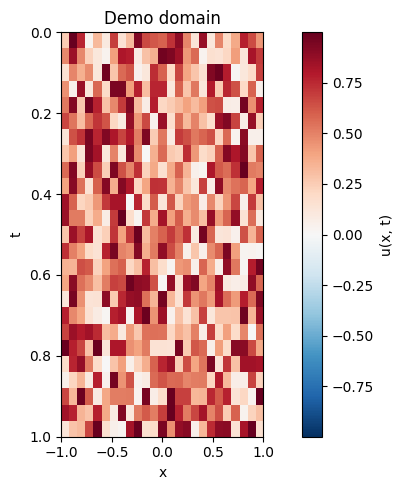

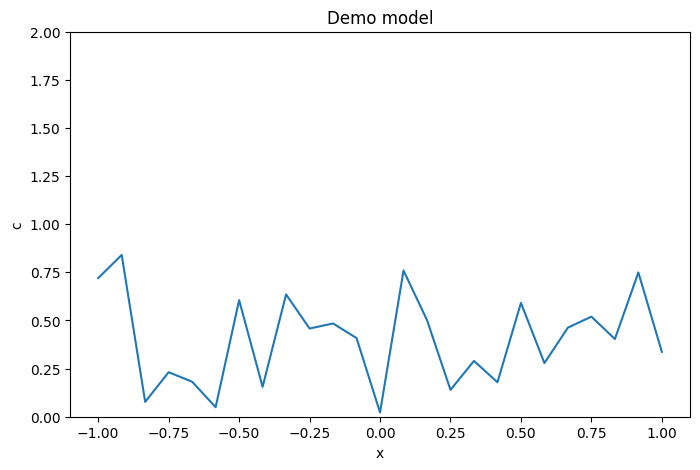

In [53]:
u = Wavefield(init_wavespeed=np.random.rand(25, 25), init_amplitude=np.random.rand(25))
u.show_domain(title='Demo domain')
u.show_model(title='Demo model')

Now, we can start to work on our loss formulation. There are a few things we need to do:

- Previously, we used `c=1`. Now, we need to update our residual to use the wavespeed model at the interior points.
- We used analytical BCs, which won't be available in an actual inversion. We need to figure out some new BCs to enforce, such as PMLs, and add a source term that will drive the forward solve.
- Further to the above, we will need to figure out where to inject our source and where to observe the wavefield, i.e., where to place our receivers. This controls the ill-posedness of the problem and will be important to get right.
- We need to add a data misfit. This will involve solving the forward problem with some target model `c_true` as the initial value to create an observed data set, then adding this in as a residual term.
- We will likely need to regularise the components, since having sparse observations will introduce a significant underdeterminism.

## PDE residual

Taking into consideration our velocity model, the updated PDE loss will become

$$\mathcal{R}_\text{PDE} = \frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} - (c_\text{interior})^2 \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2}.$$

## Boundary conditions

Now, we need to create new boundary conditions. Our previous boundary conditions are derived from the analytical solution to the 1D wave equation which is only viable since we previously assumed `c=1`. Now, we do not know `c`, it is an optimisation variable to be found. 

A nice option here are 'do-nothing' condtions: boundaries that allow travelling waves to 'leave the domain'. More formally, we can use [Engquist-Majda](https://www.jstor.org/stable/2005997?seq=1) boundary conditions which are strongly absorbing boundary conditions (ABCs) for the 1D wave equation which prevent reflections in our computational domain. These are

$$u_{t} + c u_x = 0\,\, \text{at}\,\, x = x_I,\\
u_{t} - c u_x = 0\,\, \text{at}\,\, x = 0.
$$

The first term are for rightward wave components, and the second is for the leftward components. In discrete form, we can approximate the first derivatives by finite differences to yield our new boundary condition residual terms

$$\mathcal{R}_\text{BC} = \begin{cases}
\text {Right} & \frac {u^n_{I} - u^{n-1}_{I}} {\Delta t} + c_{x_I} \frac {u^{n}_{I} - u^n_{I - 1}}{\Delta x} \\[3pt]
\text {Left} & \frac {u^n_{0} - u^{n-1}_{0}} {\Delta t} - c_{x_0} \frac {u^{n}_{1} - u^n_{0}}{\Delta x}
\end{cases}.$$

We can drop these in place of our stale Dirichlet BCs. 

## Initial conditions

Since the medium starts at rest, our initial conditions simplify also to

$$\mathcal{R}_\text{vel} = \frac {u^1_i - u^0_i} {\Delta t},\\[3pt]
\mathcal{R}_\text{IC} = u^0_i
$$

## Source term

We also require a source term. Since we have rid ourselves of the analytical solution, we need something to drive the movement of the wave in the domain. For this, we will use the [1D Ricker wavelet](https://grokipedia.com/page/Ricker_wavelet):

$$\psi(t) = (1 - 2\pi^2 f^2 t^2)e^{-\pi^2 f^2 t^2},$$

where $f$ is the peak frequency. We can just precompute this. Then, with our source term our PDE residual changes once again to its final form:

$$\mathcal{R}_\text{PDE} = \frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} - (c_\text{interior})^2 \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2} - \psi^n.$$

## Data loss 

We will need to create a data loss term in place of our prior analytical BC comparison points. This will take the form

$$\mathcal{R}_\text{data} = u^n_i - d^n_i,$$

where $d$ is some observed data which we can generate by solving the forward problem using the true model which we wish to obtain. This is the equivalent of our 'field data'.

## Summary of changes

Our full functional for the 1D FWI case is

$$L(u) = \|\mathcal{R}_\text{PDE}\|^2 + \|\mathcal{R}_\text{cond}\|^2 + \|\mathcal{R}_\text{data}\|^2,$$

where

$$\mathcal{R}_\text{cond} = \mathcal{R}_\text{IC} + \mathcal{R}_\text{vel} + \mathcal{R}_\text{left} + \mathcal{R}_\text{right}.$$

First, we will create a new class to represent ur acqusition geometry. Then, we will plug this into our discrete loss class along with the updated residual terms.

In [54]:
import torch

In [ ]:
class AcquisitionGeometry:
    u: Wavefield
    source_idx: int
    recv_idx: torch.Tensor
    source: torch.Tensor
    ts: float
    
    def __init__(self, u: Wavefield, recv_idx: torch.Tensor, f_peak: float=2.0, time_shift: float=0.1, num_recvs: int=3, source_idx: int=1):
        self.u = u
        self.source_idx = source_idx

        if recv_idx is None:
            # compute receiver indices, offset from source 
            self.recv_idx = torch.linspace(self.source_idx + 2, u.I - 1, num_recvs, dtype=torch.int).long()
        else:
            self.recv_idx = recv_idx.long()

        self.f_peak = f_peak
        self.time_shift = time_shift

        self.source = torch.zeros((u.N, u.I), dtype=torch.float64)
        self.source[:, self.source_idx] = self.ricker_source() # ricker source across time at the source loc

    # compute 1D Ricker source term
    def ricker_source(self) -> torch.Tensor:
        t = torch.linspace(self.u.t_0, self.u.t_N, self.u.N, dtype=torch.float64)
        amplitude = (torch.pi**2) * (self.f_peak**2) * ((t - self.time_shift)**2)
        return (1 - 2*amplitude) * torch.exp(-amplitude)
    
    def show_source(self):
        fig, ax = plt.subplots(figsize=(8, 4))
        ts = np.linspace(self.u.t_0, self.u.t_N, self.u.N)
        ax.plot(ts, self.source[:, self.source_idx])
        ax.set_title("Ricker source")
        ax.set_ylabel("Amplitude")
        ax.set_xlabel("Time")
        plt.show()

    def show_geometry(self):
        fig, ax = plt.subplots(figsize=(8, 4))
        xs = np.linspace(self.u.x_0, self.u.x_I, self.u.I)

        recv_x = self.u.x_0 + self.recv_idx.numpy() * self.u.dx
        source_x = self.u.x_0 + self.source_idx * self.u.dx

        ax.plot(xs, np.zeros_like(xs), 'k-', label='Spatial domain')
        ax.scatter(recv_x, np.zeros(len(recv_x)), color='r', marker='v', s=80, label='Receivers', zorder=5)
        ax.scatter([source_x], [0], color='b', marker='*', s=150, label='Source', zorder=5)
        ax.get_yaxis().set_visible(False)
        ax.set_xlabel("x")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [110]:
class Discrete1DFWILoss:
    def __init__(self, u: Wavefield, d_obs: Wavefield, geometry: AcquisitionGeometry, omega: float = 2.0):
        self.u = u
        self.d_obs = torch.tensor(d_obs.amplitude, dtype=torch.float64).reshape(u.N, u.I)
        self.geometry = geometry
        self.omega = omega # data weight

        # normalisation terms
        self.Nc = self.u.N * self.u.I
        self.N_data = self.u.N * len(self.geometry.recv_idx)

        self.history = {k: [] for k in
                        ("R_pde", "R_ic", "R_vel", "R_left", "R_right", "R_data", "L")}

    # evaluate full loss and gradient
    def evaluate(self, params: np.ndarray) -> Tuple[float, np.ndarray]:
        p = torch.tensor(params, requires_grad=True, dtype=torch.float64)
        R = self._compute_residuals(p)
        L = self._loss(R)
        self._log(R, L)
        L.backward()
        grad = p.grad if p.grad is not None else torch.zeros_like(p)
        return L.item(), grad.numpy()

    def _loss(self, R: dict) -> torch.Tensor:
        physics_sq = sum((R[k] ** 2).sum()
                        for k in ("R_pde", "R_ic", "R_vel", "R_left", "R_right"))
        data_sq = (R["R_data"] ** 2).sum()
        return physics_sq / self.Nc + (self.omega ** 2 / self.N_data) * data_sq # extract physics-related losses
        
        data_sq = (R["R_data"] ** 2).sum()
        return physics_sq / self.Nc + (self.omega ** 2 / self.N_data) * data_sq # weight each component

    def _compute_residuals(self, p_flat: torch.Tensor) -> dict:

        # extract amplitude field
        u_flat = p_flat[:self.u.wavespeed_idx]
        p = u_flat.reshape(self.u.shape)

        # PDE residual
        utt = (p[2:, 1:-1] - 2 * p[1:-1, 1:-1] + p[:-2, 1:-1]) / self.u.dt ** 2
        uxx = (p[1:-1, 2:] - 2 * p[1:-1, 1:-1] + p[1:-1, :-2]) / self.u.dx ** 2

        # extract interior wavefield and source points
        c = p_flat[self.u.wavespeed_idx:]
        c_int = c[1:-1]
        f_int = self.geometry.source[1:-1, 1:-1]

        # get recv indices
        recv = self.geometry.recv_idx

        return {
            "R_pde": (utt - c_int ** 2 * uxx - f_int).ravel(), # pde term utt - c^2uxx - f = 0
            "R_ic": p[0, :], # initial condition
            "R_vel": (p[1, :] - p[0, :]) / self.u.dt, # velocity condition
            "R_left": (p[1:, 0]  - p[:-1, 0])  / self.u.dt - c[0]  * (p[1:, 1]  - p[1:, 0])  / self.u.dx, # right BC
            "R_right": (p[1:, -1] - p[:-1, -1]) / self.u.dt + c[-1] * (p[1:, -1] - p[1:, -2]) / self.u.dx, # left BC
            "R_data": (p[:, recv] - self.d_obs[:, recv]).ravel(), # data at receivers
        }

    # extract residual terms for logging
    def _log(self, R: dict, L: torch.Tensor) -> None:
        for k, v in R.items():
            self.history[k].append(v.norm().item())
        self.history["L"].append(L.item())

    def plot_history(self, title: str = "Residual history"):
        if not self.history["R_pde"]:
            raise BufferError("Detected history of length 0. Please optimise before plotting.")
        labels = {
            "R_pde": r"$\|\mathcal{R}_\mathrm{PDE}\|$", "R_ic": r"$\|\mathcal{R}_\mathrm{ic}\|$",
            "R_vel": r"$\|\mathcal{R}_\mathrm{vel}\|$", "R_left": r"$\|\mathcal{R}_\mathrm{left}\|$",
            "R_right": r"$\|\mathcal{R}_\mathrm{right}\|$", "R_data": r"$\|\mathcal{R}_\mathrm{data}\|$",
            "L": r"$L(u_i^n)$",
        }
        # extract keys and setup subplots
        keys = list(self.history.keys())
        ncols, n = 4, len(keys)
        nrows = int(np.ceil(n / ncols))
        fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

        # plot history
        for ax, key in zip(axs.ravel(), keys):
            ax.plot(np.arange(len(self.history[key])), self.history[key])
            ax.set_xlabel("Function evaluation")
            ax.set_title(labels.get(key, key))
            ax.set_yscale("log")
        
        # make spare axes invisible
        for ax in axs.ravel()[n:]:
            ax.set_visible(False)
        
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()

Now, all we have left to do is define our observed data that will enforce the data residual term. The simplest approach I can think to do this through is by defining a target wavespeed model and running a finite differnce simulation to solve the wave equation in accordance with that model. Let's write up a function to do so.

In [111]:
def generate_observed_data(u: Wavefield, c_true: np.ndarray, geometry: AcquisitionGeometry) -> np.ndarray:
    N, I = u.N, u.I
    dt, dx = u.dt, u.dx

    wavefield = np.zeros((N, I))

    # define our ricker source
    t = np.linspace(u.t_0, u.t_N, N)
    ricker = geometry.ricker_source().numpy()

    # create source mask for injection locations
    src_mask = (np.arange(1, I-1) == geometry.source_idx)

    for n in range(1, N - 1):
        uxx = (wavefield[n, 2:] - 2*wavefield[n, 1:-1] + wavefield[n, :-2]) / dx**2
        wavefield[n+1, 1:-1] = (2 * wavefield[n, 1:-1] - wavefield[n-1, 1:-1] 
                                + (c_true[1:-1] * dt)**2 * uxx
                                + dt**2 * ricker[n] * src_mask
                                )
        
        # absorbing BCs
        nu_l = c_true[0]  * dt / dx
        nu_r = c_true[-1] * dt / dx
        wavefield[n+1, 0]  = (wavefield[n, 0]  + nu_l * wavefield[n+1, 1])  / (1 + nu_l)
        wavefield[n+1, -1] = (wavefield[n, -1] + nu_r * wavefield[n+1, -2]) / (1 + nu_r)

    return wavefield

Finally, we can run ODIL to invert for a wavespeed model. Let's try inverting from a starting model of ones.

In [64]:
import scipy.optimize as scopt
import time

In [115]:
def run_odil(u: Wavefield, functional: Discrete1DFWILoss, 
             method="L-BFGS-B", 
             field_plot_title="ODIL", history_plot_title="Residual history", 
             maxiter=50000, ftol=1e-12, gtol=1e-8):

    opts = {'maxiter': maxiter} if method == 'Newton-CG' else {'maxiter': maxiter, 'maxfun': maxiter*200, 'ftol': ftol, 'gtol': gtol}
    
    # get bounds for L-BFGS-B
    n_amp = u.N*u.I
    n_c = u.I
    bounds = [(None, None)] * n_amp + [(1e-1, None)] * n_c # clamp wavespeed to strictly positive 

    start = time.time()
    result = scopt.minimize(
        functional.evaluate,
        x0=u._data.copy(),
        jac=True, # evaluate returns loss, grad together
        method=method,
        bounds=bounds if method=='L-BFGS-B' else None,
        options=opts
    )
    end = time.time()

    convergence = result["success"]
    print(f"Convergence: {" achieved" if convergence else " failed"}", )
    print("Exit reason:", result.message)
    if convergence: print("Iterations:", result.nit)
    print("Wall time:", end - start)

    u._data = result.x
    u.show_domain(field_plot_title)
    u.show_model("Wavespeed model")

    functional.plot_history(history_plot_title)

    return u

Now, let's string this all together and try to run the ODIL. All we need to do now is define the starting model for the wavespeed.

In [146]:
# create wavefield
u = Wavefield()

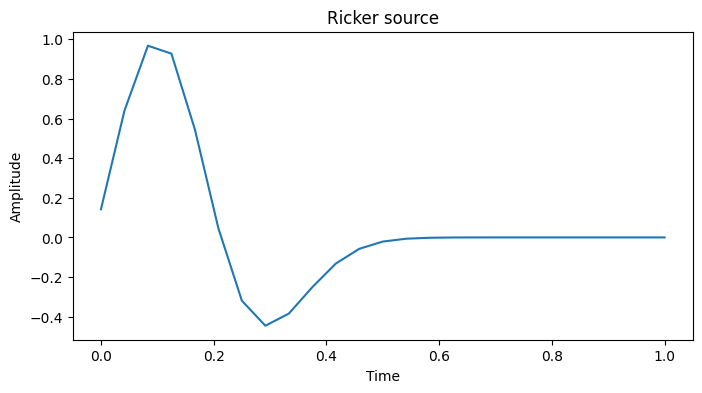

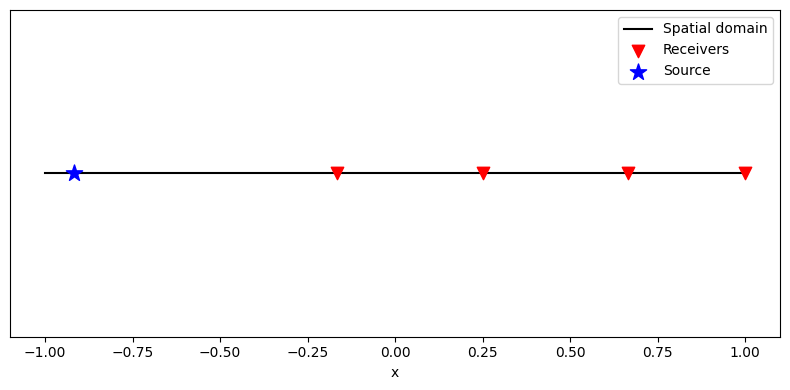

In [154]:
# setup geometry
geom = AcquisitionGeometry(u, recv_idx=torch.Tensor([10, 15, 20, 24]), f_peak=2.0)
geom.show_source()
geom.show_geometry()

In [155]:
c_true = np.ones(u.I)
c_max = 1.5
c_true[5:10] = c_max # central velocity anomaly

print("CFL satisfied:", c_max * u.dt / u.dx <= 1 )

CFL satisfied: True


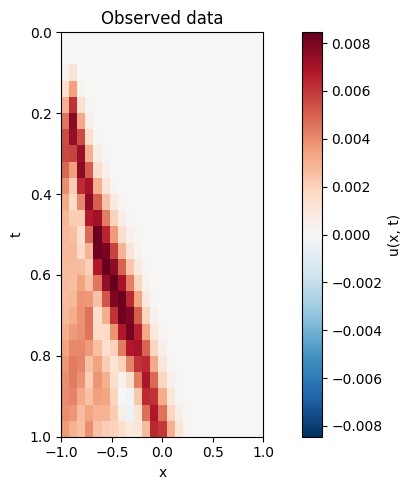

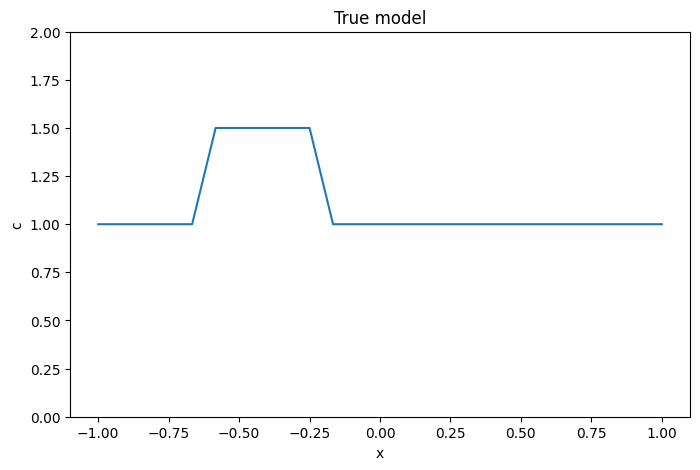

In [156]:
# compute our observed data
wavefield_true = generate_observed_data(u, c_true, geom)

# wrap in a wavefield to give to the functional
d_obs = Wavefield(init_amplitude=wavefield_true, init_wavespeed=c_true)
d_obs.show_domain("Observed data")
d_obs.show_model("True model")

In [157]:
# create our functional
functional = Discrete1DFWILoss(u=u, d_obs=d_obs, geometry=geom)

In [158]:
# run the ODIL
run_odil(u, functional)

IndexError: tensors used as indices must be long, int, byte or bool tensors